In [1]:
import implicit.nearest_neighbours
import torch
from tqdm import tqdm_notebook
from tqdm import tqdm
import pandas as pd
import os
import numpy as np
from scipy.sparse import csr_matrix
from collections import defaultdict
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE, SpectralEmbedding
import umap

from scipy.sparse.linalg import svds

In [2]:
%matplotlib widget

In [3]:
data_dir = "data"
data_types = ["flat"]
files = ["multi_event"]
dataset_dict = {}

In [ ]:
# Загрузка датасетов
for dtype in data_types:
    dataset_dict[dtype] = {}
    for fname in files:
        path = os.path.join(data_dir, dtype, f"{fname}.parquet")
        if os.path.exists(path):
            dataset_dict[dtype][fname] = pd.read_parquet(path)
            print(f"Loaded {dtype}/{fname} with shape {dataset_dict[dtype][fname].shape}")
        else:
            print(f"File {path} not found!")

In [10]:
multi_event = dataset_dict["flat"]["multi_event"]

# Основные статистики
print(multi_event['event_type'].value_counts())
print("=====")
print(multi_event['uid'].nunique(), "unique users")
print("=====")
print(multi_event['item_id'].nunique(), "unique tracks")

# Среднее количество событий на пользователя
print("=====")
avg_events_per_user = multi_event.groupby('uid').size().mean()
print("Average events per user:", avg_events_per_user)

event_type
listen       46467212
like           881456
unlike         312972
dislike        107776
undislike       21033
Name: count, dtype: int64
=====
10000 unique users
=====
934057 unique tracks
=====
Average events per user: 4779.0449


In [11]:
# Очистка данных: удаление редких пользователей и треков
min_user_events = 5
min_track_events = 5

user_counts = multi_event['uid'].value_counts()
track_counts = multi_event['item_id'].value_counts()

multi_event = multi_event[
    multi_event['uid'].isin(user_counts[user_counts >= min_user_events].index) &
    multi_event['item_id'].isin(track_counts[track_counts >= min_track_events].index)
]

In [12]:
# Преобразование событий в числовую шкалу
EVENT_WEIGHTS = {
    "listen": lambda r: r / 100 if r is not None else 0.3,
    "like": lambda _: 3.0,
    "dislike": lambda _: -2.0,
    "unlike": lambda _: -1.0,
    "undislike": lambda _: -0.5,
}

In [13]:
def compute_event_score(row):
    fn = EVENT_WEIGHTS[row.event_type]
    return fn(row.played_ratio_pct)

In [14]:
multi_event['event_score'] = multi_event.apply(compute_event_score, axis=1)

In [4]:
output_path = os.path.join(data_dir, "flat", "multi_event_processed.parquet")

In [ ]:
multi_event.to_parquet(output_path, index=False)
print(f"Saved processed multi_event to {output_path}")

In [6]:
multi_event = pd.read_parquet(output_path)

In [7]:
# Разделение на train/test (по времени для последовательных моделей)
multi_event = multi_event.sort_values(['uid', 'timestamp'])
train_events = []
test_events = []

for user, group in multi_event.groupby('uid'):
    n = len(group)
    if n < 2:
        train_events.append(group)
        continue
    split_idx = int(n * 0.8)
    train_events.append(group.iloc[:split_idx])
    test_events.append(group.iloc[split_idx:])

train_df = pd.concat(train_events)
test_df = pd.concat(test_events)

In [8]:
# Формирование матрицы user × track для ALS/SVD
users = train_df['uid'].unique()
items = train_df['item_id'].unique()

user2idx = {u: i for i, u in enumerate(users)}
item2idx = {t: i for i, t in enumerate(items)}

train_user_idx = train_df['uid'].map(user2idx)
train_track_idx = train_df['item_id'].map(item2idx)
train_scores = train_df['event_score'].values

train_matrix = csr_matrix(
    (train_scores, (train_user_idx, train_track_idx)),
    shape=(len(users), len(items))
)

In [9]:
print(f"Train events: {len(train_df)}, Test events: {len(test_df)}")
print(f"Unique users: {len(users)}, Unique tracks: {len(items)}")

Train events: 37469436, Test events: 9372369
Unique users: 10000, Unique tracks: 360787


In [10]:
X = train_matrix

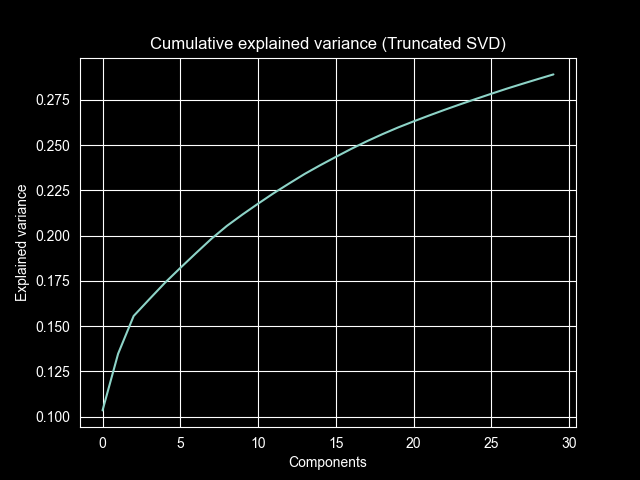

In [48]:
# Truncated SVD (основа для sparse)

svd = TruncatedSVD(n_components=30, random_state=42)
X_svd = svd.fit_transform(X)

plt.figure()
plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.title("Cumulative explained variance (Truncated SVD)")
plt.xlabel("Components")
plt.ylabel("Explained variance")
plt.show()

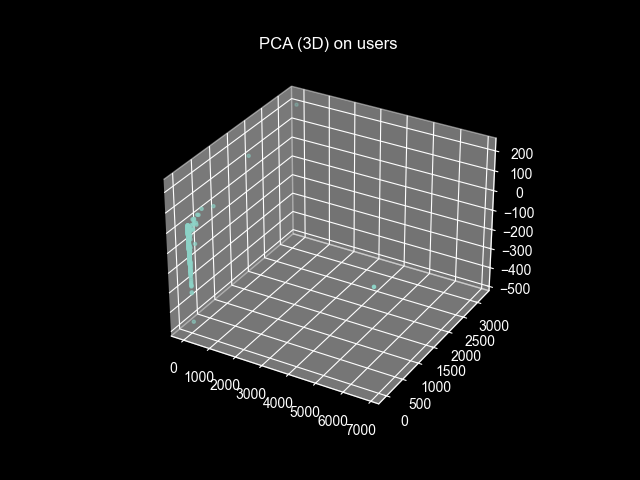

In [49]:
# PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], s=5)
ax.set_title("PCA (3D) on users")
plt.show()

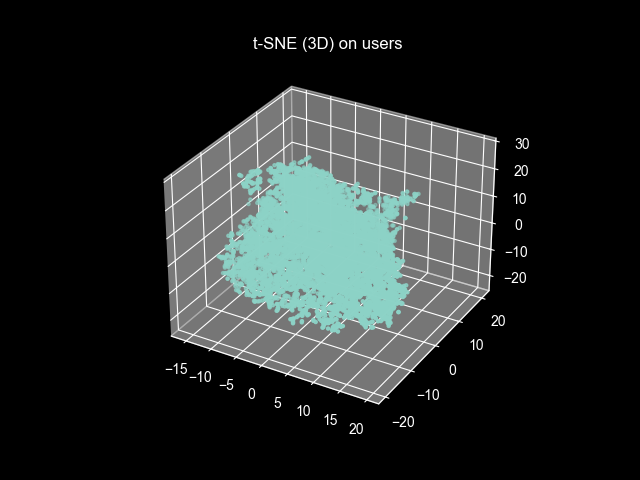

In [50]:
# t-SNE

tsne = TSNE(n_components=3)
X_tsne = tsne.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_tsne[:,0], X_tsne[:,1], X_tsne[:,2], s=5)
ax.set_title("t-SNE (3D) on users")
plt.show()

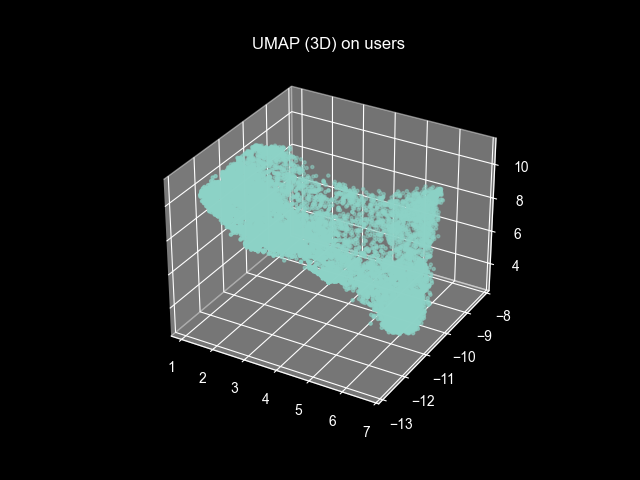

In [52]:
# UMAP

reducer = umap.UMAP(n_components=3)
X_umap = reducer.fit_transform(X)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_umap[:,0], X_umap[:,1], X_umap[:,2], s=5)
ax.set_title("UMAP (3D) on users")
plt.show()

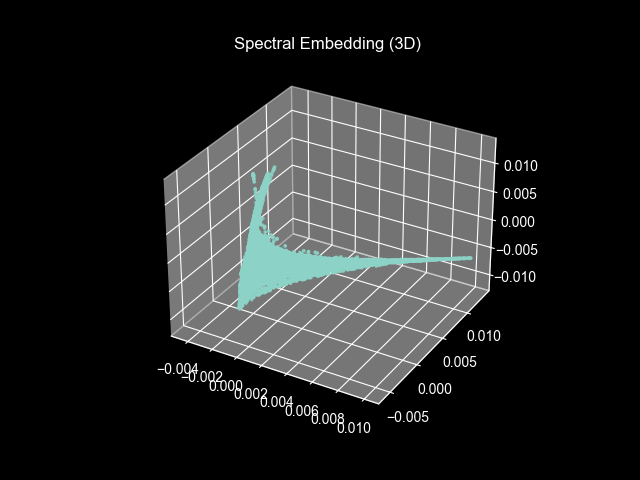

In [54]:
spec = SpectralEmbedding(
    n_components=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42)

X_spec = spec.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X_spec[:,0], X_spec[:,1], X_spec[:,2], s=3)
ax.set_title("Spectral Embedding (3D)")
plt.show()

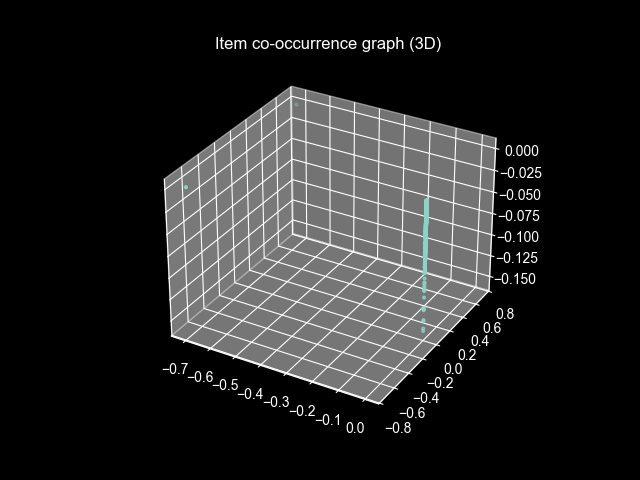

In [55]:
top_k = 850

item_popularity = np.array(train_matrix.sum(axis=0)).ravel()
top_items = np.argsort(item_popularity)[-top_k:]

X_top = train_matrix[:, top_items].T
cooc = (X_top @ X_top.T).toarray().astype(np.float32)

np.fill_diagonal(cooc, 0)

# layout через SVD
U, _, _ = np.linalg.svd(cooc, full_matrices=False)
coords_3d = U[:, :3]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(
    coords_3d[:, 0],
    coords_3d[:, 1],
    coords_3d[:, 2],
    s=4
)
ax.set_title("Item co-occurrence graph (3D)")
plt.show()

In [11]:
import pickle

# Popularity baseline

In [12]:
item_popularity = np.array(X.sum(axis=0)).ravel()
top_items = np.argsort(item_popularity)[::-1]

In [13]:
def recommend_popular(user_id=None, k=10):
    return top_items[:k]

# ALS (implicit MF)

In [33]:
from implicit.als import AlternatingLeastSquares

als = AlternatingLeastSquares(
    iterations=30
)

als.fit(X.T)

C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\implicit\utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.2216050624847412 seconds
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

In [14]:
with open("als_model.pkl", "wb") as f:
    pickle.dump(als, f)

In [13]:
# Загрузка
with open("als_model.pkl", "rb") as f:
    als = pickle.load(f)

In [15]:
def recommend_als(uid, k):
    u = user2idx.get(uid)
    if u is None:
        return []

    ids, scores = als.recommend(
        userid=u,
        user_items=None,
        N=k,
        filter_already_liked_items=False
    )

    return [items[i] for i in ids]

# Item-based kNN (co-occurrence)

In [17]:
from sklearn.neighbors import NearestNeighbors

# Настройка KNN для item-item
K_neighbors = 100  # количество соседей для модели
nn_model = NearestNeighbors(n_neighbors=K_neighbors, metric='cosine', algorithm='brute')
print("Обучение начато")
nn_model.fit(train_matrix.T)  # items x users
print("Обучение окончено")

Обучение начато
Обучение окончено


In [17]:
from joblib import dump, load

In [23]:
# Сохранение модели на диск
dump(nn_model, "itemknn_model.joblib")

['itemknn_model.joblib']

In [18]:
# Когда нужно использовать снова
nn_model = load("itemknn_model.joblib")

In [25]:
import numpy as np
from tqdm import tqdm

batch_size = 1000  # размер блока колонок для обработки
all_distances = []
all_neighbors = []

n_items = train_matrix.shape[1]

for start in tqdm(range(0, n_items, batch_size), desc="Обработка items"):
    end = min(start + batch_size, n_items)
    distances, neighbors = nn_model.kneighbors(train_matrix.T[start:end])
    all_distances.append(distances)
    all_neighbors.append(neighbors)

# Собираем результаты в одну матрицу
distances = np.vstack(all_distances)
neighbors_idx = np.vstack(all_neighbors)

# Словарь для быстрого доступа к соседям
item_to_neighbors = {i: neighbors_idx[i] for i in range(n_items)}

Обработка items: 100%|██████████| 361/361 [25:30<00:00,  4.24s/it]


In [ ]:
# Сохраняем
np.save('knn_neighbors.npy', neighbors_idx)
np.save('knn_distances.npy', distances)

with open('item_to_neighbors.pkl', 'wb') as f:
    pickle.dump(item_to_neighbors, f)

In [19]:
# Загружаем
neighbors_idx = np.load('knn_neighbors.npy')
distances = np.load('knn_distances.npy')

with open('item_to_neighbors.pkl', 'rb') as f:
    item_to_neighbors = pickle.load(f)

In [ ]:
# item_to_neighbors[item] — массив соседей
# distances[item] — расстояния до соседей

item_neighbors_sim = {}
for item, neighbors in tqdm(item_to_neighbors.items()):
    sims = 1 - distances[item]  # преобразуем в similarity
    item_neighbors_sim[item] = dict(zip(neighbors, sims))

In [20]:
from scipy.sparse import csr_matrix
import numpy as np

n_items = train_matrix.shape[1]
K_neighbors = neighbors_idx.shape[1]

rows = []
cols = []
data = []

MIN_SIM = 0.05

for item in tqdm(range(n_items)):
    sims = 1 - distances[item]
    neighs = neighbors_idx[item]

    for n, s in zip(neighs, sims):
        if s > MIN_SIM and n != item:
            rows.append(item)
            cols.append(n)
            data.append(s)

W = csr_matrix((data, (rows, cols)), shape=(n_items, n_items))
W.eliminate_zeros()

100%|██████████| 360787/360787 [00:18<00:00, 19366.08it/s]


In [21]:
def recommend_itemknn_sparse(uid, k=10):
    if uid not in user2idx:
        return top_items[:k].tolist()

    u_idx = user2idx[uid]

    user_vector = train_matrix[u_idx]

    scores = user_vector @ W
    scores = scores.toarray().ravel()

    scores[user_vector.indices] = 0

    if scores.sum() == 0:
        return []

    top_k = np.argpartition(scores, -k)[-k:]
    top_k = top_k[np.argsort(scores[top_k])[::-1]]

    return top_k.tolist()

# Markov / Session-based transitions

In [28]:
from collections import defaultdict

transitions = defaultdict(lambda: defaultdict(int))

for u, g in train_df.groupby("uid"):
    seq = g.sort_values("timestamp").item_id.values
    for a, b in zip(seq[:-1], seq[1:]):
        transitions[a][b] += 1

In [29]:
def recommend_markov(uid, k):
    last = train_df[train_df.uid == uid].iloc[-1].item_id
    next_items = transitions.get(last)
    if not next_items:
        return recommend_popular(k)
    return sorted(next_items, key=next_items.get, reverse=True)[:k]


# Метрики

In [23]:
K = 1000  # top-K рекомендации

def recall_at_k(y_true, y_pred, k=K):
    return int(y_true in y_pred[:k])

def precision_at_k(y_true, y_pred, k=K):
    return int(y_true in y_pred[:k]) / k

def mrr_at_k(y_true, y_pred, k=K):
    for idx, pred in enumerate(y_pred[:k]):
        if pred == y_true:
            return 1 / (idx + 1)
    return 0

def ndcg_at_k(y_true, y_pred, k=K):
    for idx, pred in enumerate(y_pred[:k]):
        if pred == y_true:
            return 1 / np.log2(idx + 2)  # idx+2 т.к. log2(1) = 0
    return 0

def evaluate_model(model_fn, test_df, k=10):
    recalls, precisions, mrrs, ndcgs = [], [], [], []

    for uid, group in tqdm(
        test_df.groupby('uid'),
        desc="Evaluating",
        total=test_df['uid'].nunique()
    ):
        true_items = set(group.item_id.values)
        if len(true_items) == 0:
            continue

        recs = model_fn(uid, k)
        if len(recs) == 0:
            continue

        # hits в топ-K
        hits = [1 if r in true_items else 0 for r in recs[:k]]
        num_hits = sum(hits)

        # Recall@K
        recalls.append(num_hits / len(true_items))

        # Precision@K
        precisions.append(num_hits / k)

        # MRR@K
        mrr = 0
        for i, r in enumerate(recs[:k]):
            if r in true_items:
                mrr = 1 / (i + 1)
                break
        mrrs.append(mrr)

        # NDCG@K
        dcg = 0
        for i, r in enumerate(recs[:k]):
            if r in true_items:
                dcg = 1 / np.log2(i + 2)
                break
        ndcgs.append(dcg)

    return {
        "Recall@K": np.mean(recalls),
        "Precision@K": np.mean(precisions),
        "MRR@K": np.mean(mrrs),
        "NDCG@K": np.mean(ndcgs)
    }


In [30]:
# Вычисление метрик
results = {}
models = {
    "Popularity": recommend_popular,
    "ALS": recommend_als,
    "Markov": recommend_markov,
    "ItemKNN": recommend_itemknn_sparse
}

for name, fn in models.items():
    results[name] = evaluate_model(fn, test_df, k=K)

results_df = pd.DataFrame(results).T
print(results_df)

Evaluating: 100%|██████████| 10000/10000 [02:28<00:00, 67.30it/s]

            Recall@K  Precision@K     MRR@K    NDCG@K
Popularity  0.000000     0.000000  0.000000  0.000000
ALS         0.000948     0.012803  0.049511  0.094975
Markov      0.030007     0.149857  0.495970  0.573032
ItemKNN     0.000002     0.000027  0.000126  0.000256


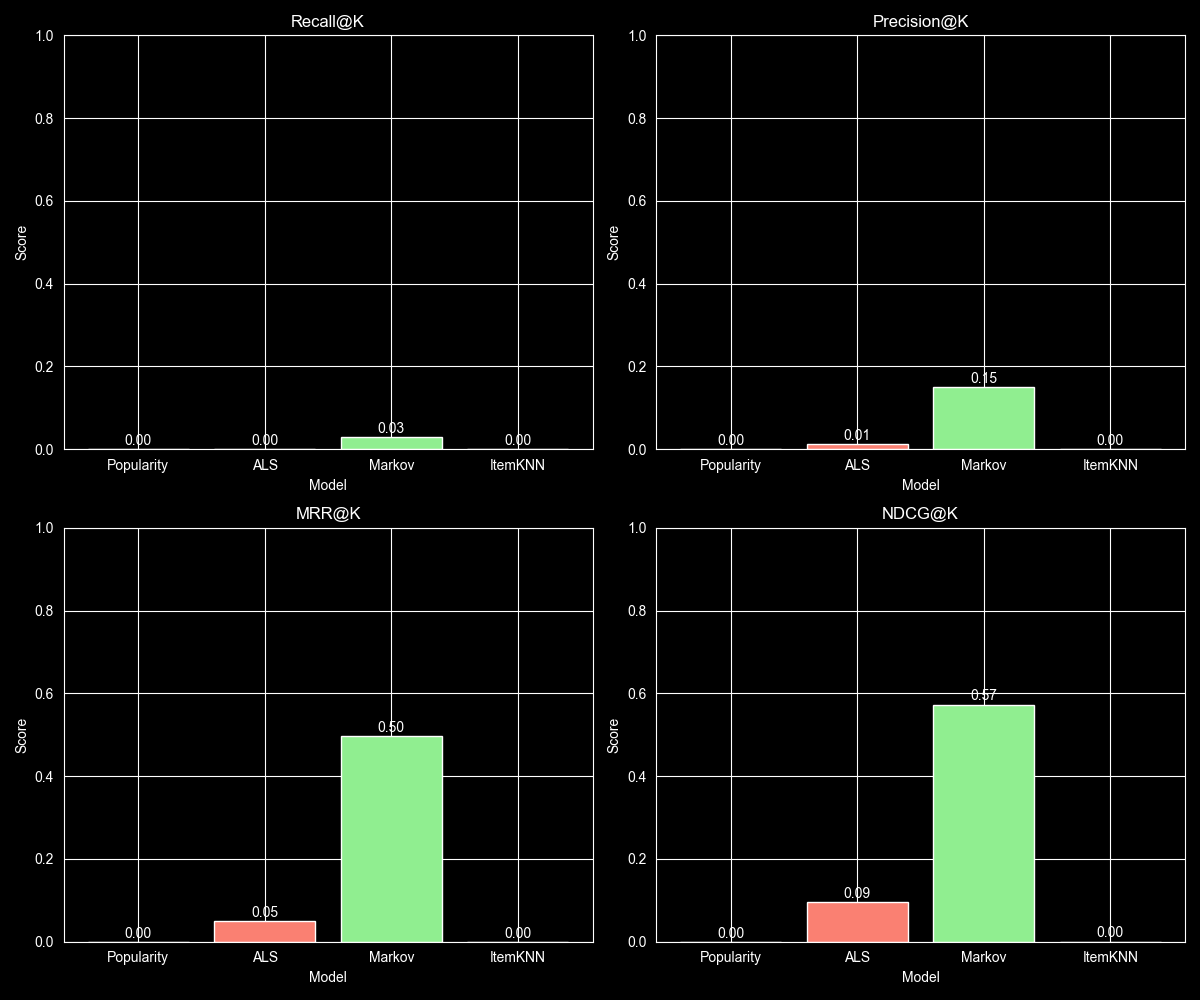

In [32]:
metrics = ["Recall@K", "Precision@K", "MRR@K", "NDCG@K"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=['skyblue','salmon','lightgreen','orange'])
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Score")
    axes[i].set_xlabel("Model")
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [41]:
def recall_at_k_multi(true_items, recs, k):
    if len(true_items) == 0:
        return 0.0
    return len(set(recs[:k]) & true_items) / len(true_items)

def evaluate_itemknn(model_fn, test_df, k=50):
    recalls = []

    for uid, group in tqdm(test_df.groupby('uid')):
        true_items = set(group.item_id.values)
        if not true_items:
            continue

        recs = model_fn(uid, k)
        if len(recs) == 0:
            continue

        recall = recall_at_k_multi(true_items, recs, k)
        recalls.append(recall)

    return {
        f"Recall@K": np.mean(recalls)
    }

def recall_per_user(model_fn, test_df, k=50):
    recalls = []

    for uid, group in tqdm(test_df.groupby('uid')):
        true_items = set(group.item_id.values)
        if not true_items:
            continue

        recs = model_fn(uid, k)
        if len(recs) == 0:
            continue

        recalls.append(
            len(set(recs[:k]) & true_items) / len(true_items)
        )

    return np.array(recalls)


In [44]:
results_knn = {}

models_knn = {
    "Popularity": recommend_popular,
    "ALS": recommend_als,
    "Markov": recommend_markov,
    "ItemKNN": recommend_itemknn_sparse
}


for name, fn in models_knn.items():
    results_knn[name] = evaluate_itemknn(fn, test_df, k=1000)

results_df_knn = pd.DataFrame(results).T
print(results_df_knn)

100%|██████████| 10000/10000 [03:29<00:00, 47.69it/s]

            Recall@K  Precision@K     MRR@K    NDCG@K
Popularity  0.000000     0.000000  0.000000  0.000000
ALS         0.000948     0.012803  0.049511  0.094975
Markov      0.030007     0.149857  0.495970  0.573032
ItemKNN     0.000002     0.000027  0.000126  0.000256


In [45]:
recall_distributions = {
    name: recall_per_user(fn, test_df, k=1000)
    for name, fn in models_knn.items()
}

100%|██████████| 10000/10000 [06:23<00:00, 26.06it/s]


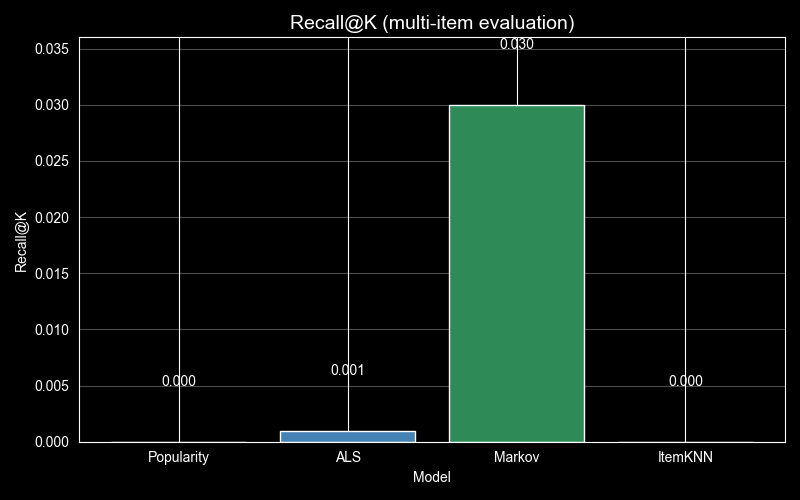

In [46]:
plt.figure(figsize=(8, 5))
plt.bar(
    results_df_knn.index,
    results_df_knn["Recall@K"],
    color=["gray", "steelblue", "seagreen", "darkorange"]
)

plt.title("Recall@K (multi-item evaluation)", fontsize=14)
plt.ylabel("Recall@K")
plt.xlabel("Model")
plt.ylim(0, results_df_knn["Recall@K"].max() * 1.2)

for i, val in enumerate(results_df_knn["Recall@K"]):
    plt.text(i, val + 0.005, f"{val:.3f}", ha="center")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Vlad\AppData\Local\Temp\ipykernel_24248\4292600235.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


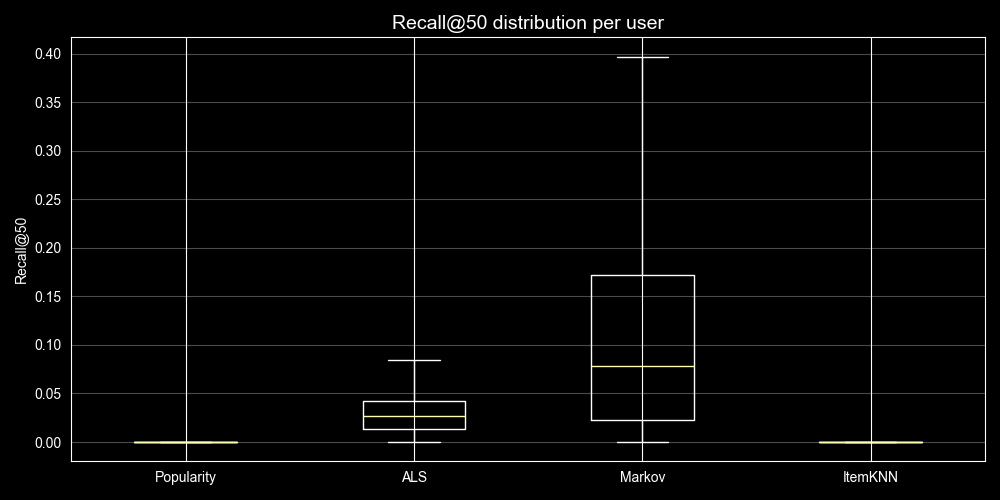

In [47]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    recall_distributions.values(),
    labels=recall_distributions.keys(),
    showfliers=False
)

plt.title("Recall@50 distribution per user", fontsize=14)
plt.ylabel("Recall@50")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
